In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\updated_data.csv")

In [4]:
X = df.drop(["label","sentence_support_information"],axis=1)
y = df["label"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)


def documents_to_text(documents):
    if isinstance(documents, (list, tuple, np.ndarray)):
        return " ".join(map(str, documents))
    return str(documents)


X_train_text = (
    X_train["question"].fillna("") + " " +
    X_train["documents"].apply(documents_to_text) + " " +
    X_train["response"].fillna("")
)

X_test_text = (
    X_test["question"].fillna("") + " " +
    X_test["documents"].apply(documents_to_text) + " " +
    X_test["response"].fillna("")
)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)



X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

Accuracy: 0.7768924302788844
Macro F1: 0.6636908532707757
                    precision    recall  f1-score   support

          GROUNDED       0.82      0.81      0.81      9457
      HALLUCINATED       0.88      0.80      0.84      8115
PARTIALLY_GROUNDED       0.28      0.43      0.34      1504

          accuracy                           0.78     19076
         macro avg       0.66      0.68      0.66     19076
      weighted avg       0.80      0.78      0.79     19076



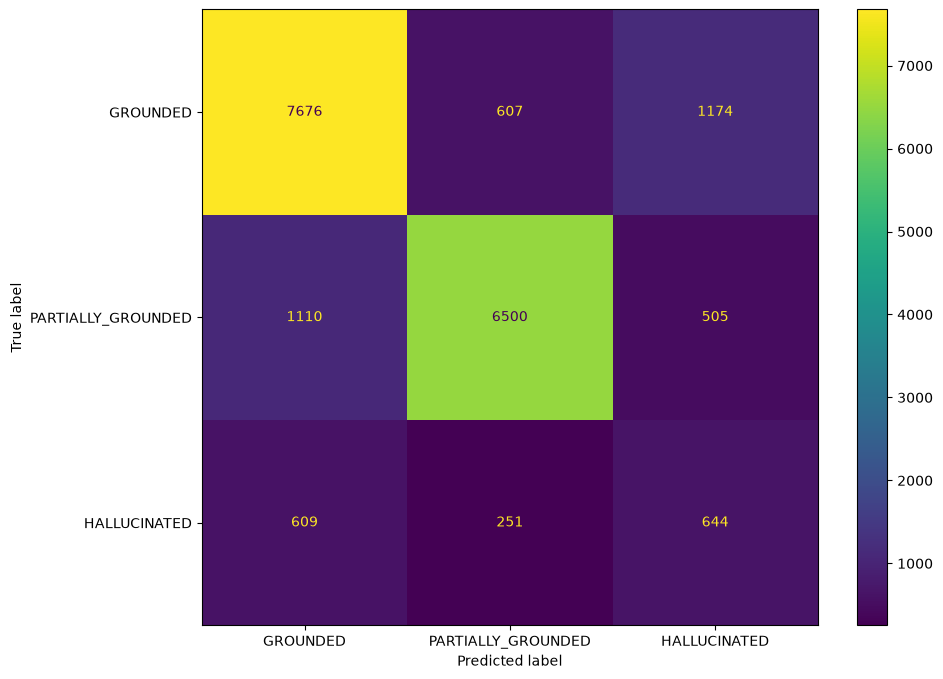

In [7]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(pd.Series(y_train_smote).value_counts())

Before:
label
GROUNDED              37827
HALLUCINATED          32461
PARTIALLY_GROUNDED     6014
Name: count, dtype: int64

After:
label
GROUNDED              37827
HALLUCINATED          37827
PARTIALLY_GROUNDED    37827
Name: count, dtype: int64


Accuracy: 0.7459635143635982
Macro F1: 0.651094801325934
                    precision    recall  f1-score   support

          GROUNDED       0.84      0.74      0.79      9457
      HALLUCINATED       0.87      0.79      0.83      8115
PARTIALLY_GROUNDED       0.24      0.55      0.34      1504

          accuracy                           0.75     19076
         macro avg       0.65      0.69      0.65     19076
      weighted avg       0.81      0.75      0.77     19076



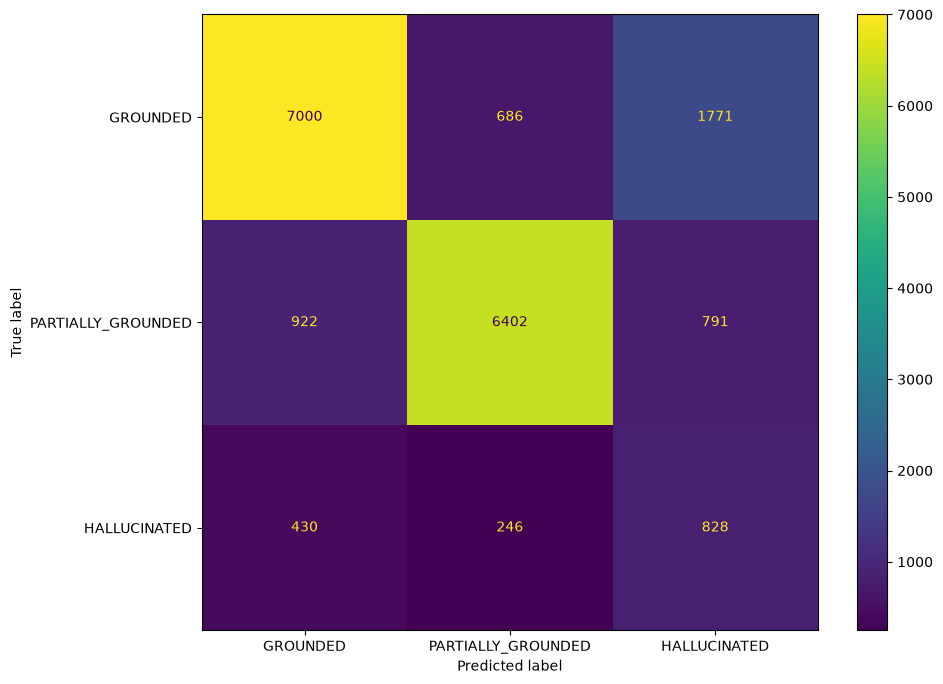

In [9]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train_smote, y_train_smote)

svm_pred = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()